In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap

mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 350,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "text.usetex": True,
    "text.latex.preamble": r'\usepackage{amsfonts}',
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9.5,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Helper to size figures relative to LaTeX \linewidth (adjust textwidth_pt if needed)
def set_fig_width(width_fraction=0.9, textwidth_pt=426.79135, height_ratio=0.6):
    inches_per_pt = 1.0/72.27
    fig_width = textwidth_pt * inches_per_pt * width_fraction
    fig_height = fig_width * height_ratio
    return (fig_width, fig_height)


In [2]:
references_df = pd.read_csv('References.csv')
references_df.info
references_df = references_df.dropna(subset=['Topic 1'])
references_df.info

<bound method DataFrame.info of      Ref n°                                            Authors  \
0         1                               GM Wagnild, HM Young   
1         2                         L Campbell‐Sills, MB Stein   
2         3                     NR Ahern, EM Kiehl, M Lou Sole   
3         4                      G Windle, KM Bennett, J Noyes   
4         5              Y Wu, W Yu, X Wu, H Wan, Y Wang, G Lu   
..      ...                                                ...   
334     335        Ziemke, T., Schaefer, K. E., & Endsley, M.    
335     336  Maher, M., Kaziunas, E., Ackerman, M., Derry, ...   
336     337                          Eakin, H., & Luers, A. L.   
337     338  Arnold, J. L., Levine, B. N., Manmatha, R., Le...   
338     339                                      Hollnagel, E.   

                                                 Title  Unnamed: 3  \
0    Development and Psychometric Evaluation of the...         NaN   
1    Psychometric analysis and refi

In [3]:
topic_1_list = references_df['Topic 1'].dropna().tolist()
print(topic_1_list)
methodology_1_list = references_df['Methodology 1'].dropna().tolist()
print(methodology_1_list)

print(len(topic_1_list), len(methodology_1_list))

topic_2_list = references_df['Topic 2'].dropna().tolist()
print(topic_2_list)
methodology_2_list = references_df['Methodology 2'].dropna().tolist()
print(methodology_2_list)

print(len(topic_2_list), len(methodology_2_list))

TopicList = topic_1_list + topic_2_list
MethodologyList = methodology_1_list + methodology_2_list

['Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'CAS', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Psychology', 'Math', 'Math', 'Engineering', 'Cyber', 'Climate', 'Engineering', 'Engineering', 'Ecology', 'Ecology', 'Ecology', 'Ecology', 'CAS', 'Org', 'Org', 'Ecology', 'Ecology', 'Health', 'Psychology', 'Health', 'Health', 'Psychology', 'Psychology', 'Health', 'Ecology', 'Climate', 'Ecology', 'Ecology', 'Ecology', 'Climate', 'Climate', 'Ecology', 'Health', 'Climate', 'Health', 'Health', 'Ecology', 'Health', 'Climate', 'Climate', 'Climate', 'Ecology', 'Ecology', 'Engineering', 'Eng

In [4]:
contingency_table = pd.crosstab(pd.Series(TopicList, name='Topic'), pd.Series(MethodologyList, name='Methodology'))
print(contingency_table)

Methodology  Case Studies  Long Studies  Metrics  Net Analysis  SM  Survey  \
Topic                                                                        
CAS                     9             0        4             5  14      15   
Climate                12             2        3             3   3      10   
Cyber                   9             3        4             2   4      19   
Ecology                15             1        8             5   7      10   
Engineering             5             0        5             0  11      12   
Health                  7             7        3             2   6       4   
Math                    0             0        0             1   9       1   
Org                    22             3        3             3   1      22   
Physics                 0             0        2             0   3       2   
Psychology              5            13        7             6   4      26   

Methodology  Tech  
Topic              
CAS             1  
Cli

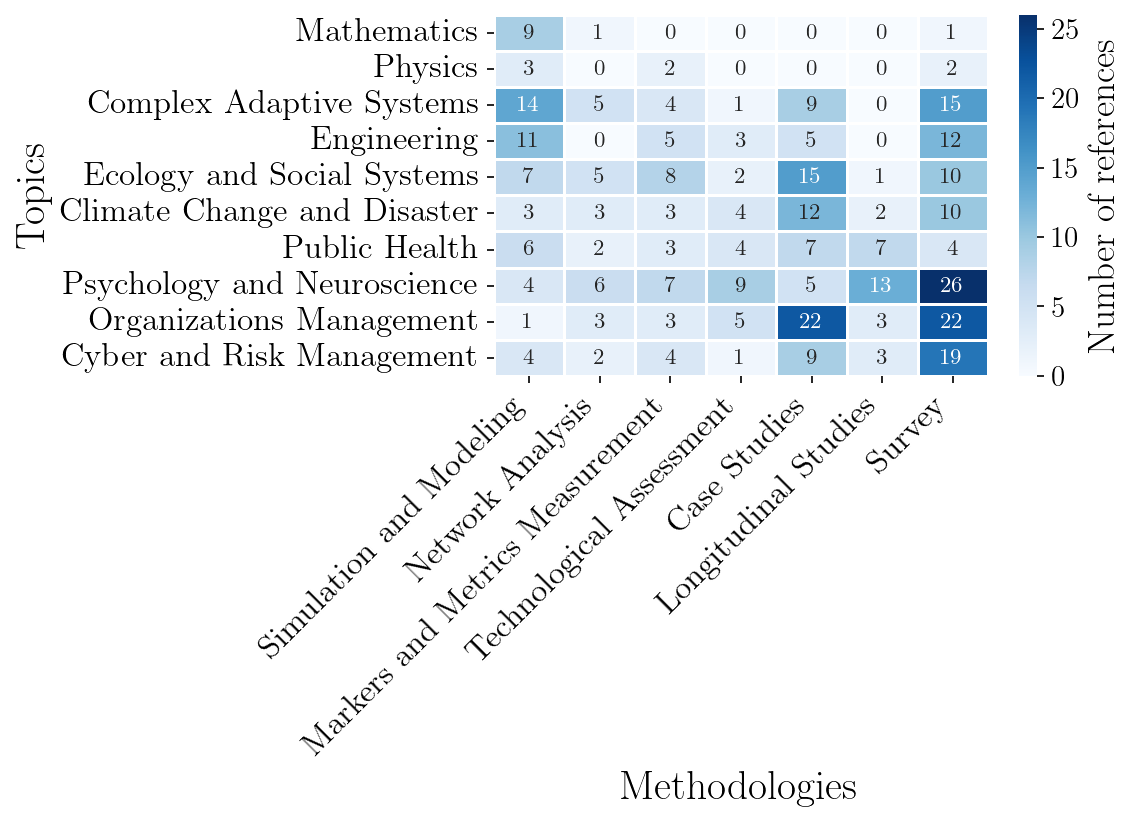

In [ ]:
# Reorder the rows and columns of the contingency table
reordered_contingency_table = contingency_table.reindex(['Math', 'Physics', 'CAS', 'Engineering', 'Ecology','Climate', 'Health', 'Psychology', 'Org', 'Cyber'] + [topic for topic in contingency_table.index if topic not in ['Math', 'Physics', 'CAS', 'Engineering', 'Ecology','Climate', 'Health', 'Psychology', 'Org', 'Cyber']])
reordered_contingency_table = reordered_contingency_table[['SM', 'Net Analysis', 'Metrics', 'Tech', 'Case Studies', 'Long Studies', 'Survey'] + [col for col in reordered_contingency_table.columns if col not in ['SM', 'Net Analysis', 'Metrics', 'Tech', 'Case Studies', 'Long Studies', 'Survey']]]

cmap = sns.color_palette("Blues", as_cmap=True)
white = np.array([1, 1, 1, 1])
cmap.set_under(white)

# Plot the heatmap with reordered data
figsize = set_fig_width(width_fraction=0.9, textwidth_pt=426.79135, height_ratio=0.6)
plt.figure(figsize=figsize)
heatmap = sns.heatmap(reordered_contingency_table, annot=True, fmt='d', linewidth=.5, cmap=cmap, vmin=0, square=True)
heatmap.set_xlabel('Methodologies', fontsize=20)
heatmap.set_ylabel('Topics', fontsize=20)
heatmap.tick_params(axis='both', which='major', labelsize=16)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label(r'Number of references', fontsize=18)

desired_order_y = ['Mathematics', 'Physics', 'Complex Adaptive Systems', 'Engineering', 'Ecology and Social Systems', 'Climate Change and Disaster', 'Public Health', 'Psychology and Neuroscience', 'Organizations Management', 'Cyber and Risk Management']
desired_order_x = ['Simulation and Modeling', 'Network Analysis', 'Markers and Metrics Measurement', 'Technological Assessment', 'Case Studies', 'Longitudinal Studies', 'Survey']
heatmap.set_yticklabels(desired_order_y, rotation=0, horizontalalignment='right')
heatmap.set_xticklabels(desired_order_x, rotation=45, horizontalalignment='right')
#heatmap.set_yticklabels(desired_order, rotation=0)


plt.savefig('HeatMap_SoA.pdf',dpi=300, bbox_inches = "tight")

plt.show()

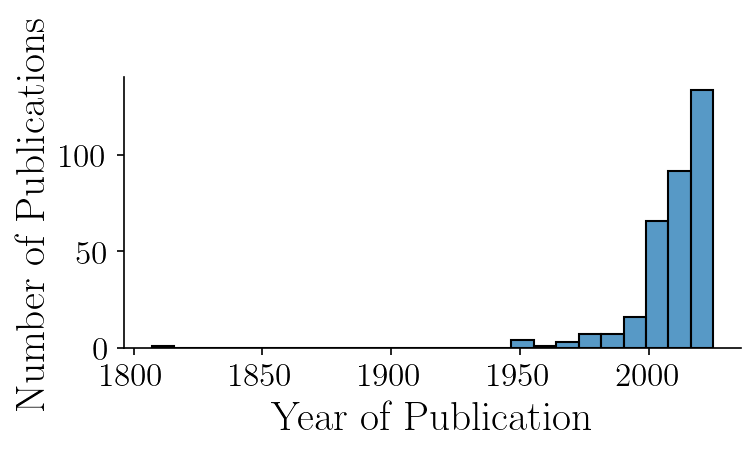

In [6]:
figsize = set_fig_width(width_fraction=0.9, textwidth_pt=426.79135, height_ratio=0.45)
plt.figure(figsize=figsize)
sns.histplot(references_df['Year'], bins=25, kde=False)
plt.xlabel('Year of Publication', fontsize=20)
plt.ylabel('Number of Publications', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()